In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import os
import json
import joblib
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Detect project root
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name.lower() == "notebooks":
    BASE_DIR = CURRENT_DIR.parent
else:
    BASE_DIR = CURRENT_DIR

ARCHIVE_DIR = BASE_DIR / "archive"
DATA_DIR = BASE_DIR / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = BASE_DIR / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("CURRENT_DIR:", CURRENT_DIR)
print("BASE_DIR:", BASE_DIR)
print("ARCHIVE_DIR:", ARCHIVE_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("MODEL_DIR:", MODEL_DIR)

CURRENT_DIR: C:\Users\Lenovo\Desktop\finsense_ml\notebooks
BASE_DIR: C:\Users\Lenovo\Desktop\finsense_ml
ARCHIVE_DIR: C:\Users\Lenovo\Desktop\finsense_ml\archive
PROCESSED_DIR: C:\Users\Lenovo\Desktop\finsense_ml\data\processed
MODEL_DIR: C:\Users\Lenovo\Desktop\finsense_ml\models


In [2]:
all_files = list(ARCHIVE_DIR.rglob("*"))

print("Total items found:", len(all_files))

for p in all_files[:50]:
    print(p.relative_to(BASE_DIR))

Total items found: 12
archive\bureau.csv
archive\bureau_balance.csv
archive\credit_card_balance.csv
archive\home-credit-default-risk
archive\HomeCredit_columns_description.csv
archive\installments_payments.csv
archive\POS_CASH_balance.csv
archive\previous_application.csv
archive\home-credit-default-risk\application_test.csv
archive\home-credit-default-risk\application_train.csv
archive\home-credit-default-risk\HomeCredit_columns_description.csv
archive\home-credit-default-risk\sample_submission.csv


In [3]:
def find_file_by_stem(root_dir, target_stem):
    """
    Finds a file by name without depending on extension visibility.
    Example: target_stem='application_train'
    """
    matches = []
    for p in root_dir.rglob("*"):
        if p.is_file() and p.stem.lower() == target_stem.lower():
            matches.append(p)
    return matches

required_stems = [
    "application_train",
    "application_test",
    "bureau",
    "bureau_balance",
    "previous_application",
    "installments_payments",
    "POS_CASH_balance",
    "credit_card_balance"
]

found_files = {}

for stem in required_stems:
    matches = find_file_by_stem(ARCHIVE_DIR, stem)
    found_files[stem] = matches

for stem, matches in found_files.items():
    print("\n", stem)
    if matches:
        for m in matches:
            print("FOUND:", m)
    else:
        print("NOT FOUND")


 application_train
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\home-credit-default-risk\application_train.csv

 application_test
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\home-credit-default-risk\application_test.csv

 bureau
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\bureau.csv

 bureau_balance
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\bureau_balance.csv

 previous_application
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\previous_application.csv

 installments_payments
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\installments_payments.csv

 POS_CASH_balance
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\POS_CASH_balance.csv

 credit_card_balance
FOUND: C:\Users\Lenovo\Desktop\finsense_ml\archive\credit_card_balance.csv


In [4]:
application_train_files = found_files["application_train"]

if not application_train_files:
    raise FileNotFoundError("application_train.csv not found. Check inside archive/home-credit-default-risk folder.")

APP_TRAIN_PATH = application_train_files[0]

print("Loading:", APP_TRAIN_PATH)

app_train = pd.read_csv(APP_TRAIN_PATH)

print("application_train shape:", app_train.shape)
app_train.head()

Loading: C:\Users\Lenovo\Desktop\finsense_ml\archive\home-credit-default-risk\application_train.csv
application_train shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print("TARGET value counts:")
print(app_train["TARGET"].value_counts())

print("\nTARGET percentage:")
print(round(app_train["TARGET"].value_counts(normalize=True) * 100, 2))

TARGET value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

TARGET percentage:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [6]:
def load_if_found(stem):
    files = found_files.get(stem, [])
    if not files:
        print(f"{stem}: NOT FOUND")
        return None
    
    path = files[0]
    print(f"Loading {stem} from:", path)
    df = pd.read_csv(path)
    print(f"{stem} shape:", df.shape)
    return df


bureau = load_if_found("bureau")
previous_application = load_if_found("previous_application")
installments_payments = load_if_found("installments_payments")

Loading bureau from: C:\Users\Lenovo\Desktop\finsense_ml\archive\bureau.csv
bureau shape: (1716428, 17)
Loading previous_application from: C:\Users\Lenovo\Desktop\finsense_ml\archive\previous_application.csv
previous_application shape: (1670214, 37)
Loading installments_payments from: C:\Users\Lenovo\Desktop\finsense_ml\archive\installments_payments.csv
installments_payments shape: (13605401, 8)


In [7]:
print("Rows:", app_train.shape[0])
print("Columns:", app_train.shape[1])

print("\nColumn type counts:")
print(app_train.dtypes.value_counts())

missing_df = pd.DataFrame({
    "column": app_train.columns,
    "missing_count": app_train.isnull().sum().values,
    "missing_percent": (app_train.isnull().sum().values / len(app_train)) * 100
}).sort_values("missing_percent", ascending=False)

missing_df.head(20)

Rows: 307511
Columns: 122

Column type counts:
float64    65
int64      41
object     16
Name: count, dtype: int64


,column,missing_count,missing_percent
48,COMMONAREA_AVG,214865,69.872297
62,COMMONAREA_MODE,214865,69.872297
76,COMMONAREA_MEDI,214865,69.872297
84,NONLIVINGAPARTMENTS_MEDI,213514,69.432963
70,NONLIVINGAPARTMENTS_MODE,213514,69.432963
56,NONLIVINGAPARTMENTS_AVG,213514,69.432963
86,FONDKAPREMONT_MODE,210295,68.386172
54,LIVINGAPARTMENTS_AVG,210199,68.354953
82,LIVINGAPARTMENTS_MEDI,210199,68.354953
68,LIVINGAPARTMENTS_MODE,210199,68.354953


In [8]:
app = app_train.copy()

# Replace anomaly values
if "DAYS_EMPLOYED" in app.columns:
    app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)

if "CODE_GENDER" in app.columns:
    app["CODE_GENDER"] = app["CODE_GENDER"].replace("XNA", np.nan)

# Basic financial ratios
app["CREDIT_INCOME_RATIO"] = app["AMT_CREDIT"] / app["AMT_INCOME_TOTAL"].replace(0, np.nan)
app["ANNUITY_INCOME_RATIO"] = app["AMT_ANNUITY"] / app["AMT_INCOME_TOTAL"].replace(0, np.nan)
app["ANNUITY_CREDIT_RATIO"] = app["AMT_ANNUITY"] / app["AMT_CREDIT"].replace(0, np.nan)
app["GOODS_CREDIT_RATIO"] = app["AMT_GOODS_PRICE"] / app["AMT_CREDIT"].replace(0, np.nan)

# Time-based features
app["AGE_YEARS"] = (-app["DAYS_BIRTH"]) / 365.25
app["EMPLOYED_YEARS"] = (-app["DAYS_EMPLOYED"]) / 365.25
app["REGISTRATION_YEARS"] = (-app["DAYS_REGISTRATION"]) / 365.25
app["ID_PUBLISH_YEARS"] = (-app["DAYS_ID_PUBLISH"]) / 365.25
app["EMPLOYED_AGE_RATIO"] = app["EMPLOYED_YEARS"] / app["AGE_YEARS"].replace(0, np.nan)

# Drop columns with more than 60% missing values, except ID and TARGET
missing_percent = app.isnull().mean() * 100
high_missing_cols = missing_percent[
    (missing_percent > 60) & 
    (~missing_percent.index.isin(["SK_ID_CURR", "TARGET"]))
].index.tolist()

print("High-missing columns dropped:", len(high_missing_cols))
print(high_missing_cols[:20])

app = app.drop(columns=high_missing_cols)

print("Application table after cleaning:", app.shape)
app.head()

High-missing columns dropped: 17
['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE']
Application table after cleaning: (307511, 114)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,ANNUITY_CREDIT_RATIO,GOODS_CREDIT_RATIO,AGE_YEARS,EMPLOYED_YEARS,REGISTRATION_YEARS,ID_PUBLISH_YEARS,EMPLOYED_AGE_RATIO
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,1.0,2.007889,0.121978,0.060749,0.863262,25.902806,1.744011,9.987680,5.804244,0.067329
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.0,4.790750,0.132217,0.027598,0.873211,45.900068,3.252567,3.247091,0.796715,0.070862
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.0,2.000000,0.100000,0.050000,1.000000,52.145106,0.616016,11.663244,6.929500,0.011814
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,NaN,2.316167,0.219900,0.094941,0.949845,52.032854,8.320329,26.921287,6.672142,0.159905
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0.0,4.222222,0.179963,0.042623,1.000000,54.570842,8.317591,11.802875,9.467488,0.152418


In [9]:
def build_bureau_features(bureau_df):
    b = bureau_df.copy()

    b["BUREAU_IS_ACTIVE"] = (b["CREDIT_ACTIVE"] == "Active").astype(int)
    b["BUREAU_IS_CLOSED"] = (b["CREDIT_ACTIVE"] == "Closed").astype(int)
    b["BUREAU_OVERDUE_FLAG"] = (b["CREDIT_DAY_OVERDUE"] > 0).astype(int)

    b["BUREAU_DEBT_CREDIT_RATIO"] = (
        b["AMT_CREDIT_SUM_DEBT"] / b["AMT_CREDIT_SUM"].replace(0, np.nan)
    )

    agg_dict = {
        "SK_ID_BUREAU": ["count"],
        "DAYS_CREDIT": ["mean", "min", "max"],
        "CREDIT_DAY_OVERDUE": ["mean", "max", "sum"],
        "CNT_CREDIT_PROLONG": ["mean", "sum"],
        "AMT_CREDIT_SUM": ["mean", "sum", "max"],
        "AMT_CREDIT_SUM_DEBT": ["mean", "sum", "max"],
        "AMT_CREDIT_SUM_OVERDUE": ["mean", "sum", "max"],
        "DAYS_CREDIT_ENDDATE": ["mean", "min", "max"],
        "BUREAU_IS_ACTIVE": ["sum", "mean"],
        "BUREAU_IS_CLOSED": ["sum", "mean"],
        "BUREAU_OVERDUE_FLAG": ["sum", "mean"],
        "BUREAU_DEBT_CREDIT_RATIO": ["mean", "max"]
    }

    bureau_agg = b.groupby("SK_ID_CURR").agg(agg_dict)

    bureau_agg.columns = [
        "BUREAU_" + "_".join(col).upper()
        for col in bureau_agg.columns
    ]

    bureau_agg = bureau_agg.reset_index()

    return bureau_agg


bureau_features = build_bureau_features(bureau)

print("bureau_features shape:", bureau_features.shape)
bureau_features.head()

bureau_features shape: (305811, 30)


,SK_ID_CURR,BUREAU_SK_ID_BUREAU_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_SUM,BUREAU_CNT_CREDIT_PROLONG_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,...,BUREAU_DAYS_CREDIT_ENDDATE_MIN,BUREAU_DAYS_CREDIT_ENDDATE_MAX,BUREAU_BUREAU_IS_ACTIVE_SUM,BUREAU_BUREAU_IS_ACTIVE_MEAN,BUREAU_BUREAU_IS_CLOSED_SUM,BUREAU_BUREAU_IS_CLOSED_MEAN,BUREAU_BUREAU_OVERDUE_FLAG_SUM,BUREAU_BUREAU_OVERDUE_FLAG_MEAN,BUREAU_BUREAU_DEBT_CREDIT_RATIO_MEAN,BUREAU_BUREAU_DEBT_CREDIT_RATIO_MAX
0,100001,7,-735.000000,-1572,-49,0.0,0,0,0.0,0,...,-1329.0,1778.0,3,0.428571,4,0.571429,0,0.0,0.282518,0.987405
1,100002,8,-874.000000,-1437,-103,0.0,0,0,0.0,0,...,-1072.0,780.0,2,0.250000,6,0.750000,0,0.0,0.136545,0.546180
2,100003,4,-1400.750000,-2586,-606,0.0,0,0,0.0,0,...,-2434.0,1216.0,1,0.250000,3,0.750000,0,0.0,0.000000,0.000000
3,100004,2,-867.000000,-1326,-408,0.0,0,0,0.0,0,...,-595.0,-382.0,0,0.000000,2,1.000000,0,0.0,0.000000,0.000000
4,100005,3,-190.666667,-373,-62,0.0,0,0,0.0,0,...,-128.0,1324.0,2,0.666667,1,0.333333,0,0.0,0.601256,0.954794


In [10]:
def build_previous_application_features(prev_df):
    p = prev_df.copy()

    p["PREV_APPROVED_FLAG"] = (p["NAME_CONTRACT_STATUS"] == "Approved").astype(int)
    p["PREV_REFUSED_FLAG"] = (p["NAME_CONTRACT_STATUS"] == "Refused").astype(int)

    p["PREV_CREDIT_APPLICATION_RATIO"] = (
        p["AMT_CREDIT"] / p["AMT_APPLICATION"].replace(0, np.nan)
    )

    p["PREV_ANNUITY_CREDIT_RATIO"] = (
        p["AMT_ANNUITY"] / p["AMT_CREDIT"].replace(0, np.nan)
    )

    agg_dict = {
        "SK_ID_PREV": ["count"],
        "AMT_ANNUITY": ["mean", "max"],
        "AMT_APPLICATION": ["mean", "sum", "max"],
        "AMT_CREDIT": ["mean", "sum", "max"],
        "AMT_DOWN_PAYMENT": ["mean", "max"],
        "HOUR_APPR_PROCESS_START": ["mean"],
        "RATE_DOWN_PAYMENT": ["mean", "max"],
        "DAYS_DECISION": ["mean", "min", "max"],
        "CNT_PAYMENT": ["mean", "max"],
        "PREV_APPROVED_FLAG": ["sum", "mean"],
        "PREV_REFUSED_FLAG": ["sum", "mean"],
        "PREV_CREDIT_APPLICATION_RATIO": ["mean", "max"],
        "PREV_ANNUITY_CREDIT_RATIO": ["mean", "max"]
    }

    prev_agg = p.groupby("SK_ID_CURR").agg(agg_dict)

    prev_agg.columns = [
        "PREV_" + "_".join(col).upper()
        for col in prev_agg.columns
    ]

    prev_agg = prev_agg.reset_index()

    return prev_agg


previous_features = build_previous_application_features(previous_application)

print("previous_features shape:", previous_features.shape)
previous_features.head()

previous_features shape: (338857, 28)


,SK_ID_CURR,PREV_SK_ID_PREV_COUNT,PREV_AMT_ANNUITY_MEAN,PREV_AMT_ANNUITY_MAX,PREV_AMT_APPLICATION_MEAN,PREV_AMT_APPLICATION_SUM,PREV_AMT_APPLICATION_MAX,PREV_AMT_CREDIT_MEAN,PREV_AMT_CREDIT_SUM,PREV_AMT_CREDIT_MAX,...,PREV_CNT_PAYMENT_MEAN,PREV_CNT_PAYMENT_MAX,PREV_PREV_APPROVED_FLAG_SUM,PREV_PREV_APPROVED_FLAG_MEAN,PREV_PREV_REFUSED_FLAG_SUM,PREV_PREV_REFUSED_FLAG_MEAN,PREV_PREV_CREDIT_APPLICATION_RATIO_MEAN,PREV_PREV_CREDIT_APPLICATION_RATIO_MAX,PREV_PREV_ANNUITY_CREDIT_RATIO_MEAN,PREV_PREV_ANNUITY_CREDIT_RATIO_MAX
0,100001,1,3951.000,3951.000,24835.50,24835.5,24835.5,23787.00,23787.0,23787.0,...,8.0,8.0,1,1.0,0,0.0,0.957782,0.957782,0.166099,0.166099
1,100002,1,9251.775,9251.775,179055.00,179055.0,179055.0,179055.00,179055.0,179055.0,...,24.0,24.0,1,1.0,0,0.0,1.000000,1.000000,0.051670,0.051670
2,100003,3,56553.990,98356.995,435436.50,1306309.5,900000.0,484191.00,1452573.0,1035882.0,...,10.0,12.0,3,1.0,0,0.0,1.057664,1.150980,0.126383,0.185200
3,100004,1,5357.250,5357.250,24282.00,24282.0,24282.0,20106.00,20106.0,20106.0,...,4.0,4.0,1,1.0,0,0.0,0.828021,0.828021,0.266450,0.266450
4,100005,2,4813.200,4813.200,22308.75,44617.5,44617.5,20076.75,40153.5,40153.5,...,12.0,12.0,1,0.5,0,0.0,0.899950,0.899950,0.119870,0.119870


In [11]:
def build_installment_features(inst_df):
    i = inst_df.copy()

    i["PAYMENT_DELAY"] = i["DAYS_ENTRY_PAYMENT"] - i["DAYS_INSTALMENT"]
    i["LATE_PAYMENT_FLAG"] = (i["PAYMENT_DELAY"] > 0).astype(int)

    i["PAYMENT_RATIO"] = i["AMT_PAYMENT"] / i["AMT_INSTALMENT"].replace(0, np.nan)
    i["PAYMENT_SHORTFALL"] = i["AMT_INSTALMENT"] - i["AMT_PAYMENT"]
    i["PAYMENT_SHORTFALL_FLAG"] = (i["PAYMENT_SHORTFALL"] > 0).astype(int)

    agg_dict = {
        "SK_ID_PREV": ["count"],
        "NUM_INSTALMENT_VERSION": ["nunique"],
        "NUM_INSTALMENT_NUMBER": ["max"],
        "DAYS_INSTALMENT": ["mean", "min", "max"],
        "DAYS_ENTRY_PAYMENT": ["mean", "min", "max"],
        "PAYMENT_DELAY": ["mean", "max"],
        "LATE_PAYMENT_FLAG": ["sum", "mean"],
        "AMT_INSTALMENT": ["mean", "sum", "max"],
        "AMT_PAYMENT": ["mean", "sum", "max"],
        "PAYMENT_RATIO": ["mean", "min"],
        "PAYMENT_SHORTFALL": ["mean", "sum", "max"],
        "PAYMENT_SHORTFALL_FLAG": ["sum", "mean"]
    }

    inst_agg = i.groupby("SK_ID_CURR").agg(agg_dict)

    inst_agg.columns = [
        "INST_" + "_".join(col).upper()
        for col in inst_agg.columns
    ]

    inst_agg = inst_agg.reset_index()

    return inst_agg


installment_features = build_installment_features(installments_payments)

print("installment_features shape:", installment_features.shape)
installment_features.head()

installment_features shape: (339587, 27)


,SK_ID_CURR,INST_SK_ID_PREV_COUNT,INST_NUM_INSTALMENT_VERSION_NUNIQUE,INST_NUM_INSTALMENT_NUMBER_MAX,INST_DAYS_INSTALMENT_MEAN,INST_DAYS_INSTALMENT_MIN,INST_DAYS_INSTALMENT_MAX,INST_DAYS_ENTRY_PAYMENT_MEAN,INST_DAYS_ENTRY_PAYMENT_MIN,INST_DAYS_ENTRY_PAYMENT_MAX,...,INST_AMT_PAYMENT_MEAN,INST_AMT_PAYMENT_SUM,INST_AMT_PAYMENT_MAX,INST_PAYMENT_RATIO_MEAN,INST_PAYMENT_RATIO_MIN,INST_PAYMENT_SHORTFALL_MEAN,INST_PAYMENT_SHORTFALL_SUM,INST_PAYMENT_SHORTFALL_MAX,INST_PAYMENT_SHORTFALL_FLAG_SUM,INST_PAYMENT_SHORTFALL_FLAG_MEAN
0,100001,7,2,4,-2187.714286,-2916.0,-1619.0,-2195.000000,-2916.0,-1628.0,...,5885.132143,41195.925,17397.900,1.0,1.0,0.0,0.0,0.0,0,0.0
1,100002,19,2,19,-295.000000,-565.0,-25.0,-315.421053,-587.0,-49.0,...,11559.247105,219625.695,53093.745,1.0,1.0,0.0,0.0,0.0,0,0.0
2,100003,25,2,12,-1378.160000,-2310.0,-536.0,-1385.320000,-2324.0,-544.0,...,64754.586000,1618864.650,560835.360,1.0,1.0,0.0,0.0,0.0,0,0.0
3,100004,3,2,3,-754.000000,-784.0,-724.0,-761.666667,-795.0,-727.0,...,7096.155000,21288.465,10573.965,1.0,1.0,0.0,0.0,0.0,0,0.0
4,100005,9,2,9,-586.000000,-706.0,-466.0,-609.555556,-736.0,-470.0,...,6240.205000,56161.845,17656.245,1.0,1.0,0.0,0.0,0.0,0,0.0


In [12]:
model_df = app.copy()

print("Initial app shape:", model_df.shape)

model_df = model_df.merge(bureau_features, on="SK_ID_CURR", how="left")
print("After bureau merge:", model_df.shape)

model_df = model_df.merge(previous_features, on="SK_ID_CURR", how="left")
print("After previous application merge:", model_df.shape)

model_df = model_df.merge(installment_features, on="SK_ID_CURR", how="left")
print("After installments merge:", model_df.shape)

print("Final model_df shape:", model_df.shape)
model_df.head()

Initial app shape: (307511, 114)
After bureau merge: (307511, 143)
After previous application merge: (307511, 170)
After installments merge: (307511, 196)
Final model_df shape: (307511, 196)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INST_AMT_PAYMENT_MEAN,INST_AMT_PAYMENT_SUM,INST_AMT_PAYMENT_MAX,INST_PAYMENT_RATIO_MEAN,INST_PAYMENT_RATIO_MIN,INST_PAYMENT_SHORTFALL_MEAN,INST_PAYMENT_SHORTFALL_SUM,INST_PAYMENT_SHORTFALL_MAX,INST_PAYMENT_SHORTFALL_FLAG_SUM,INST_PAYMENT_SHORTFALL_FLAG_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,11559.247105,219625.695,53093.745,1.000000,1.00000,0.000000,0.000,0.000,0.0,0.000000
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,64754.586000,1618864.650,560835.360,1.000000,1.00000,0.000000,0.000,0.000,0.0,0.000000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,7096.155000,21288.465,10573.965,1.000000,1.00000,0.000000,0.000,0.000,0.0,0.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,62947.088438,1007153.415,691786.890,1.000000,1.00000,0.000000,0.000,0.000,0.0,0.000000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,12214.060227,806127.975,22678.785,0.954545,0.00005,452.384318,29857.365,22655.655,6.0,0.090909


In [13]:
merged_path = PROCESSED_DIR / "home_credit_merged_features.csv"

model_df.to_csv(merged_path, index=False)

print("Merged model table saved to:")
print(merged_path)

Merged model table saved to:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\home_credit_merged_features.csv


In [14]:
ids = model_df["SK_ID_CURR"].copy()
target = model_df["TARGET"].astype(int)

features_raw = model_df.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")

cat_cols = features_raw.select_dtypes(include=["object"]).columns.tolist()
num_cols = features_raw.select_dtypes(exclude=["object"]).columns.tolist()

print("Total raw features:", features_raw.shape[1])
print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

print("\nCategorical columns:")
print(cat_cols)

Total raw features: 194
Numerical columns: 179
Categorical columns: 15

Categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [15]:
features_encoded = features_raw.copy()

for col in cat_cols:
    features_encoded[col] = features_encoded[col].fillna("Unknown")

features_encoded = pd.get_dummies(
    features_encoded,
    columns=cat_cols,
    dummy_na=False
)

features_encoded = features_encoded.replace([np.inf, -np.inf], np.nan)

print("Encoded feature shape:", features_encoded.shape)
features_encoded.head()

Encoded feature shape: (307511, 320)


,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,WALLSMATERIAL_MODE_Mixed,WALLSMATERIAL_MODE_Monolithic,WALLSMATERIAL_MODE_Others,WALLSMATERIAL_MODE_Panel,"WALLSMATERIAL_MODE_Stone, brick",WALLSMATERIAL_MODE_Unknown,WALLSMATERIAL_MODE_Wooden,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Unknown,EMERGENCYSTATE_MODE_Yes
0,0,202500.0,406597.5,24700.5,351000.0,0.018801,-9461,-637.0,-3648.0,-2120,...,False,False,False,False,True,False,False,True,False,False
1,0,270000.0,1293502.5,35698.5,1129500.0,0.003541,-16765,-1188.0,-1186.0,-291,...,False,False,False,False,False,False,False,True,False,False
2,0,67500.0,135000.0,6750.0,135000.0,0.010032,-19046,-225.0,-4260.0,-2531,...,False,False,False,False,False,True,False,False,True,False
3,0,135000.0,312682.5,29686.5,297000.0,0.008019,-19005,-3039.0,-9833.0,-2437,...,False,False,False,False,False,True,False,False,True,False
4,0,121500.0,513000.0,21865.5,513000.0,0.028663,-19932,-3038.0,-4311.0,-3458,...,False,False,False,False,False,True,False,False,True,False


In [16]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = 120000

full_train_df = features_encoded.copy()
full_train_df["TARGET"] = target.values
full_train_df["SK_ID_CURR"] = ids.values

model_sample_df, _ = train_test_split(
    full_train_df,
    train_size=SAMPLE_SIZE,
    stratify=full_train_df["TARGET"],
    random_state=42
)

print("Model sample shape:", model_sample_df.shape)

print("\nSample TARGET distribution:")
print(model_sample_df["TARGET"].value_counts())

print("\nSample TARGET percentage:")
print(round(model_sample_df["TARGET"].value_counts(normalize=True) * 100, 2))

Model sample shape: (120000, 322)

Sample TARGET distribution:
TARGET
0    110313
1      9687
Name: count, dtype: int64

Sample TARGET percentage:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [17]:
X = model_sample_df.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y = model_sample_df["TARGET"].astype(int)

FEATURE_COLS_REAL = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain TARGET distribution:")
print(y_train.value_counts())

print("\nTest TARGET distribution:")
print(y_test.value_counts())

X_train shape: (96000, 320)
X_test shape: (24000, 320)

Train TARGET distribution:
TARGET
0    88250
1     7750
Name: count, dtype: int64

Test TARGET distribution:
TARGET
0    22063
1     1937
Name: count, dtype: int64


In [18]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Preprocessing complete.")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Preprocessing complete.
X_train_scaled: (96000, 320)
X_test_scaled: (24000, 320)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

import time

In [20]:
start = time.time()

log_reg_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

log_reg_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained.")
print("Training time:", round(time.time() - start, 2), "seconds")

Logistic Regression trained.
Training time: 17.7 seconds


In [21]:
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=30,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest trained.")
print("Training time:", round(time.time() - start, 2), "seconds")

Random Forest trained.
Training time: 16.95 seconds


In [22]:
start = time.time()

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print("Negative class:", neg)
print("Positive class:", pos)
print("scale_pos_weight:", round(scale_pos_weight, 3))

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_scaled, y_train)

print("XGBoost trained.")
print("Training time:", round(time.time() - start, 2), "seconds")

Negative class: 88250
Positive class: 7750
scale_pos_weight: 11.387
XGBoost trained.
Training time: 13.66 seconds


In [23]:
def find_best_f1_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    precision = precision[:-1]
    recall = recall[:-1]

    f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]

    return best_threshold, precision[best_idx], recall[best_idx], f1_scores[best_idx]


def evaluate_model(model_name, model, X_test_scaled, y_test):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    best_threshold, best_precision, best_recall, best_f1 = find_best_f1_threshold(
        y_test,
        y_prob
    )

    y_pred = (y_prob >= best_threshold).astype(int)

    result = {
        "model": model_name,
        "best_threshold": best_threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

    print("=" * 70)
    print(model_name)
    print("=" * 70)
    print("Best threshold:", round(result["best_threshold"], 4))
    print("Accuracy      :", round(result["accuracy"], 4))
    print("Precision     :", round(result["precision"], 4))
    print("Recall        :", round(result["recall"], 4))
    print("F1 Score      :", round(result["f1_score"], 4))
    print("ROC-AUC       :", round(result["roc_auc"], 4))
    print("PR-AUC        :", round(result["pr_auc"], 4))

    print("\nConfusion Matrix:")
    print(result["confusion_matrix"])

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No Difficulty", "Repayment Difficulty"]
    ))

    return result

In [24]:
results = []

results.append(
    evaluate_model("Logistic Regression", log_reg_model, X_test_scaled, y_test)
)

results.append(
    evaluate_model("Random Forest", rf_model, X_test_scaled, y_test)
)

results.append(
    evaluate_model("XGBoost", xgb_model, X_test_scaled, y_test)
)

Logistic Regression
Best threshold: 0.649
Accuracy      : 0.8321
Precision     : 0.2316
Recall        : 0.4662
F1 Score      : 0.3095
ROC-AUC       : 0.766
PR-AUC        : 0.243

Confusion Matrix:
[[19067  2996]
 [ 1034   903]]

Classification Report:
                      precision    recall  f1-score   support

       No Difficulty       0.95      0.86      0.90     22063
Repayment Difficulty       0.23      0.47      0.31      1937

            accuracy                           0.83     24000
           macro avg       0.59      0.67      0.61     24000
        weighted avg       0.89      0.83      0.86     24000

Random Forest
Best threshold: 0.4998
Accuracy      : 0.823
Precision     : 0.224
Recall        : 0.4843
F1 Score      : 0.3063
ROC-AUC       : 0.7604
PR-AUC        : 0.2336

Confusion Matrix:
[[18814  3249]
 [  999   938]]

Classification Report:
                      precision    recall  f1-score   support

       No Difficulty       0.95      0.85      0.90     22063
R

In [25]:
comparison_df = pd.DataFrame([
    {
        "model": r["model"],
        "best_threshold": r["best_threshold"],
        "accuracy": r["accuracy"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1_score": r["f1_score"],
        "roc_auc": r["roc_auc"],
        "pr_auc": r["pr_auc"]
    }
    for r in results
])

comparison_df = comparison_df.sort_values(
    by=["roc_auc", "pr_auc", "f1_score"],
    ascending=False
).reset_index(drop=True)

comparison_df

,model,best_threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,XGBoost,0.681955,0.874583,0.294680,0.397522,0.338462,0.778402,0.266154
1,Logistic Regression,0.649027,0.832083,0.231598,0.466185,0.309459,0.765997,0.243015
2,Random Forest,0.499800,0.823000,0.224027,0.484254,0.306336,0.760354,0.233555


In [26]:
comparison_path = PROCESSED_DIR / "model_comparison_real_data.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Saved model comparison to:")
print(comparison_path)

Saved model comparison to:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\model_comparison_real_data.csv


In [27]:
comparison_path = PROCESSED_DIR / "model_comparison_real_data.csv"
comparison_df.to_csv(comparison_path, index=False)

print("Saved model comparison to:")
print(comparison_path)

Saved model comparison to:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\model_comparison_real_data.csv


In [28]:
final_model = xgb_model
final_model_name = "XGBoost"

best_xgb_row = comparison_df[comparison_df["model"] == "XGBoost"].iloc[0]
BEST_THRESHOLD = float(best_xgb_row["best_threshold"])

print("Final selected model:", final_model_name)
print("Best threshold:", BEST_THRESHOLD)
print("ROC-AUC:", round(best_xgb_row["roc_auc"], 4))
print("PR-AUC:", round(best_xgb_row["pr_auc"], 4))
print("F1-score:", round(best_xgb_row["f1_score"], 4))

Final selected model: XGBoost
Best threshold: 0.681954562664032
ROC-AUC: 0.7784
PR-AUC: 0.2662
F1-score: 0.3385


In [30]:
model_path = MODEL_DIR / "xgb_model.pkl"
imputer_path = MODEL_DIR / "imputer.pkl"
scaler_path = MODEL_DIR / "scaler.pkl"
feature_cols_path = MODEL_DIR / "feature_cols_real.json"
metadata_path = MODEL_DIR / "model_metadata.json"

joblib.dump(final_model, model_path)
joblib.dump(imputer, imputer_path)
joblib.dump(scaler, scaler_path)

with open(feature_cols_path, "w") as f:
    json.dump(FEATURE_COLS_REAL, f, indent=4)

metadata = {
    "model_name": "XGBoost",
    "dataset": "Home Credit Default Risk",
    "target_meaning": {
        "0": "No repayment difficulty",
        "1": "Repayment difficulty / default risk"
    },
    "best_threshold": BEST_THRESHOLD,
    "metrics": {
        "accuracy": float(best_xgb_row["accuracy"]),
        "precision": float(best_xgb_row["precision"]),
        "recall": float(best_xgb_row["recall"]),
        "f1_score": float(best_xgb_row["f1_score"]),
        "roc_auc": float(best_xgb_row["roc_auc"]),
        "pr_auc": float(best_xgb_row["pr_auc"])
    },
    "num_features": len(FEATURE_COLS_REAL),
    "risk_score_logic": "risk_score = predicted_probability * 100"
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved:")
print(model_path)
print(imputer_path)
print(scaler_path)
print(feature_cols_path)
print(metadata_path)

Saved:
C:\Users\Lenovo\Desktop\finsense_ml\models\xgb_model.pkl
C:\Users\Lenovo\Desktop\finsense_ml\models\imputer.pkl
C:\Users\Lenovo\Desktop\finsense_ml\models\scaler.pkl
C:\Users\Lenovo\Desktop\finsense_ml\models\feature_cols_real.json
C:\Users\Lenovo\Desktop\finsense_ml\models\model_metadata.json


In [36]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

booster = final_model.get_booster()

print("XGBoost booster loaded for SHAP-style contributions.")

XGBoost version: 3.2.0
XGBoost booster loaded for SHAP-style contributions.


In [38]:
def get_xgb_shap_values(X_scaled_array):
    """
    Uses XGBoost's built-in pred_contribs=True.
    Returns:
    - shap_values: feature contribution values
    - base_values: model bias term
    """
    dmatrix = xgb.DMatrix(
        X_scaled_array,
        feature_names=FEATURE_COLS_REAL
    )

    contribs = booster.predict(
        dmatrix,
        pred_contribs=True
    )

    # Last column is bias/base value
    shap_values = contribs[:, :-1]
    base_values = contribs[:, -1]

    return shap_values, base_values


print("SHAP helper ready.")

SHAP helper ready.


In [39]:
SHAP_SAMPLE_SIZE = 500

X_test_scaled_sample = X_test_scaled[:SHAP_SAMPLE_SIZE]
X_test_sample_df = X_test.iloc[:SHAP_SAMPLE_SIZE].copy()

shap_values, base_values = get_xgb_shap_values(X_test_scaled_sample)

print("SHAP values shape:", shap_values.shape)
print("Base values shape:", base_values.shape)

SHAP values shape: (500, 320)
Base values shape: (500,)


In [40]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": FEATURE_COLS_REAL,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_importance_df.head(20)

,feature,mean_abs_shap
0,EXT_SOURCE_2,0.347013
1,EXT_SOURCE_3,0.260749
2,EXT_SOURCE_1,0.143679
3,AMT_ANNUITY,0.113414
4,GOODS_CREDIT_RATIO,0.110992
5,INST_AMT_PAYMENT_SUM,0.102558
6,INST_LATE_PAYMENT_FLAG_MEAN,0.100677
7,BUREAU_BUREAU_DEBT_CREDIT_RATIO_MAX,0.092465
8,ANNUITY_CREDIT_RATIO,0.086362
9,CODE_GENDER_F,0.079022


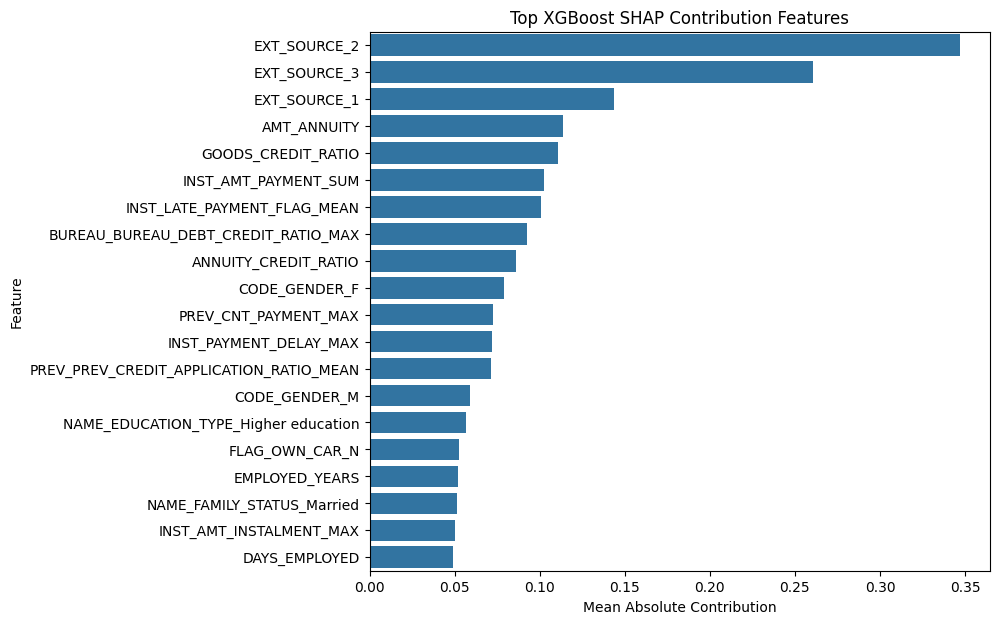

In [41]:
top_n = 20

plt.figure(figsize=(8, 7))
sns.barplot(
    data=shap_importance_df.head(top_n),
    x="mean_abs_shap",
    y="feature"
)
plt.title("Top XGBoost SHAP Contribution Features")
plt.xlabel("Mean Absolute Contribution")
plt.ylabel("Feature")
plt.show()

In [42]:
def score_to_tier(score):
    if score < 30:
        return "green"
    elif score < 55:
        return "amber"
    elif score < 75:
        return "orange"
    else:
        return "red"


def tier_action(tier):
    actions = {
        "green": "Healthy borrower. No immediate action required.",
        "amber": "Early stress. Send automated check-in message.",
        "orange": "High risk. Officer review and restructuring offer recommended.",
        "red": "Pre-default risk. Immediate branch escalation recommended."
    }
    return actions.get(tier, "Unknown")


print("Tier mapping loaded.")

Tier mapping loaded.


In [43]:
def humanize_feature_name(feature):
    replacements = {
        "EXT_SOURCE_1": "External credit score 1",
        "EXT_SOURCE_2": "External credit score 2",
        "EXT_SOURCE_3": "External credit score 3",
        "AMT_CREDIT": "Loan credit amount",
        "AMT_ANNUITY": "Loan annuity / EMI amount",
        "AMT_INCOME_TOTAL": "Total income",
        "CREDIT_INCOME_RATIO": "Credit-to-income ratio",
        "ANNUITY_INCOME_RATIO": "Annuity-to-income ratio",
        "ANNUITY_CREDIT_RATIO": "Annuity-to-credit ratio",
        "AGE_YEARS": "Borrower age",
        "EMPLOYED_YEARS": "Employment duration",
        "EMPLOYED_AGE_RATIO": "Employment-to-age ratio",
        "INST_PAYMENT_DELAY_MEAN": "Average installment payment delay",
        "INST_PAYMENT_DELAY_MAX": "Maximum installment payment delay",
        "INST_LATE_PAYMENT_FLAG_MEAN": "Late payment rate",
        "INST_LATE_PAYMENT_FLAG_SUM": "Total late payments",
        "INST_PAYMENT_SHORTFALL_MEAN": "Average payment shortfall",
        "INST_PAYMENT_SHORTFALL_SUM": "Total payment shortfall",
        "BUREAU_CREDIT_DAY_OVERDUE_MAX": "Maximum bureau overdue days",
        "BUREAU_CREDIT_DAY_OVERDUE_SUM": "Total bureau overdue days",
        "BUREAU_BUREAU_OVERDUE_FLAG_SUM": "Bureau overdue events",
        "BUREAU_AMT_CREDIT_SUM_DEBT_SUM": "Total bureau debt",
        "PREV_PREV_REFUSED_FLAG_MEAN": "Previous application refusal rate",
        "PREV_PREV_REFUSED_FLAG_SUM": "Previous refused applications",
    }

    if feature in replacements:
        return replacements[feature]

    return feature.replace("_", " ").title()


print("Feature label helper loaded.")

Feature label helper loaded.


In [44]:
def predict_finsense_risk(row_index):
    """
    row_index is index position inside X_test.
    Returns FinSense-style risk output for one borrower.
    """
    raw_row = X_test.iloc[[row_index]]
    borrower_id = int(model_sample_df.loc[X_test.index[row_index], "SK_ID_CURR"])

    row_imputed = imputer.transform(raw_row)
    row_scaled = scaler.transform(row_imputed)

    probability = float(final_model.predict_proba(row_scaled)[0, 1])
    score = round(probability * 100, 2)
    tier = score_to_tier(score)

    row_shap_values, row_base_values = get_xgb_shap_values(row_scaled)
    row_shap = row_shap_values[0]

    shap_dict = {
        feature: float(value)
        for feature, value in zip(FEATURE_COLS_REAL, row_shap)
    }

    top_items = sorted(
        shap_dict.items(),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:8]

    top_risk_factors = []

    for feature, contribution_value in top_items:
        top_risk_factors.append({
            "feature": feature,
            "human_label": humanize_feature_name(feature),
            "impact": round(abs(contribution_value), 4),
            "direction": "increasing_risk" if contribution_value > 0 else "decreasing_risk",
            "contribution_value": round(contribution_value, 4)
        })

    return {
        "borrower_id": borrower_id,
        "probability": round(probability, 6),
        "risk_score": score,
        "risk_tier": tier,
        "recommended_action": tier_action(tier),
        "top_risk_factors": top_risk_factors
    }


sample_output = predict_finsense_risk(0)
sample_output

{'borrower_id': 183702,
 'probability': 0.146302,
 'risk_score': 14.63,
 'risk_tier': 'green',
 'recommended_action': 'Healthy borrower. No immediate action required.',
 'top_risk_factors': [{'feature': 'EXT_SOURCE_3',
   'human_label': 'External credit score 3',
   'impact': 0.3986,
   'direction': 'decreasing_risk',
   'contribution_value': -0.3986},
  {'feature': 'ANNUITY_CREDIT_RATIO',
   'human_label': 'Annuity-to-credit ratio',
   'impact': 0.3435,
   'direction': 'decreasing_risk',
   'contribution_value': -0.3435},
  {'feature': 'EXT_SOURCE_2',
   'human_label': 'External credit score 2',
   'impact': 0.2773,
   'direction': 'decreasing_risk',
   'contribution_value': -0.2773},
  {'feature': 'PREV_PREV_CREDIT_APPLICATION_RATIO_MEAN',
   'human_label': 'Prev Prev Credit Application Ratio Mean',
   'impact': 0.141,
   'direction': 'increasing_risk',
   'contribution_value': 0.141},
  {'feature': 'INST_LATE_PAYMENT_FLAG_MEAN',
   'human_label': 'Late payment rate',
   'impact': 0.

In [45]:
test_probs = final_model.predict_proba(X_test_scaled)[:, 1]

highest_risk_idx = int(np.argmax(test_probs))

print("Highest risk row index:", highest_risk_idx)
print("Highest risk probability:", round(test_probs[highest_risk_idx], 6))
print("Highest risk score:", round(test_probs[highest_risk_idx] * 100, 2))

high_risk_output = predict_finsense_risk(highest_risk_idx)
high_risk_output

Highest risk row index: 2327
Highest risk probability: 0.966676
Highest risk score: 96.67


{'borrower_id': 304421,
 'probability': 0.966676,
 'risk_score': 96.67,
 'risk_tier': 'red',
 'recommended_action': 'Pre-default risk. Immediate branch escalation recommended.',
 'top_risk_factors': [{'feature': 'EXT_SOURCE_2',
   'human_label': 'External credit score 2',
   'impact': 0.8612,
   'direction': 'increasing_risk',
   'contribution_value': 0.8612},
  {'feature': 'INST_LATE_PAYMENT_FLAG_MEAN',
   'human_label': 'Late payment rate',
   'impact': 0.1737,
   'direction': 'increasing_risk',
   'contribution_value': 0.1737},
  {'feature': 'ANNUITY_CREDIT_RATIO',
   'human_label': 'Annuity-to-credit ratio',
   'impact': 0.138,
   'direction': 'increasing_risk',
   'contribution_value': 0.138},
  {'feature': 'PREV_PREV_REFUSED_FLAG_MEAN',
   'human_label': 'Previous application refusal rate',
   'impact': 0.1257,
   'direction': 'increasing_risk',
   'contribution_value': 0.1257},
  {'feature': 'INST_NUM_INSTALMENT_NUMBER_MAX',
   'human_label': 'Inst Num Instalment Number Max',
  

In [46]:
test_scores_df = pd.DataFrame({
    "SK_ID_CURR": model_sample_df.loc[X_test.index, "SK_ID_CURR"].values,
    "actual_TARGET": y_test.values,
    "predicted_probability": test_probs,
    "risk_score": np.round(test_probs * 100, 2)
})

test_scores_df["risk_tier"] = test_scores_df["risk_score"].apply(score_to_tier)
test_scores_df["recommended_action"] = test_scores_df["risk_tier"].apply(tier_action)

high_risk_leaderboard = test_scores_df.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

high_risk_leaderboard.head(20)

,SK_ID_CURR,actual_TARGET,predicted_probability,risk_score,risk_tier,recommended_action
0,304421,1,0.966676,96.669998,red,Pre-default risk. Immediate branch escalation ...
1,269598,1,0.960772,96.080002,red,Pre-default risk. Immediate branch escalation ...
2,320907,0,0.956958,95.699997,red,Pre-default risk. Immediate branch escalation ...
3,374276,1,0.948080,94.809998,red,Pre-default risk. Immediate branch escalation ...
4,181065,1,0.945623,94.559998,red,Pre-default risk. Immediate branch escalation ...
5,219786,0,0.945406,94.540001,red,Pre-default risk. Immediate branch escalation ...
6,454088,1,0.944763,94.480003,red,Pre-default risk. Immediate branch escalation ...
7,135388,1,0.940033,94.000000,red,Pre-default risk. Immediate branch escalation ...
8,226520,0,0.936204,93.620003,red,Pre-default risk. Immediate branch escalation ...
9,337857,1,0.934668,93.470001,red,Pre-default risk. Immediate branch escalation ...


In [47]:
print("Risk tier distribution:")
print(test_scores_df["risk_tier"].value_counts())

print("\nRisk tier percentage:")
print(round(test_scores_df["risk_tier"].value_counts(normalize=True) * 100, 2))

Risk tier distribution:
risk_tier
green     10514
amber      7954
orange     4013
red        1519
Name: count, dtype: int64

Risk tier percentage:
risk_tier
green     43.81
amber     33.14
orange    16.72
red        6.33
Name: proportion, dtype: float64


In [48]:
leaderboard_path = PROCESSED_DIR / "high_risk_borrowers_sample.csv"

high_risk_leaderboard.to_csv(leaderboard_path, index=False)

print("Saved high-risk borrower leaderboard to:")
print(leaderboard_path)

Saved high-risk borrower leaderboard to:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\high_risk_borrowers_sample.csv


In [49]:
shap_importance_path = PROCESSED_DIR / "xgboost_shap_importance.csv"

shap_importance_df.to_csv(shap_importance_path, index=False)

print("Saved SHAP importance to:")
print(shap_importance_path)

Saved SHAP importance to:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\xgboost_shap_importance.csv


In [50]:
demo_risk_output_path = PROCESSED_DIR / "demo_high_risk_output.json"

with open(demo_risk_output_path, "w") as f:
    json.dump(high_risk_output, f, indent=4)

print("Saved demo high-risk output to:")
print(demo_risk_output_path)

Saved demo high-risk output to:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\demo_high_risk_output.json


In [51]:
risk_scores_sample = []

top_100 = high_risk_leaderboard.head(100)

for _, row in top_100.iterrows():
    risk_scores_sample.append({
        "borrower_id": int(row["SK_ID_CURR"]),
        "actual_TARGET": int(row["actual_TARGET"]),
        "probability": round(float(row["predicted_probability"]), 6),
        "risk_score": round(float(row["risk_score"]), 2),
        "risk_tier": row["risk_tier"],
        "recommended_action": row["recommended_action"]
    })

risk_scores_sample_path = PROCESSED_DIR / "risk_scores_sample.json"

with open(risk_scores_sample_path, "w") as f:
    json.dump(risk_scores_sample, f, indent=4)

print("Saved risk scores sample to:")
print(risk_scores_sample_path)

Saved risk scores sample to:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\risk_scores_sample.json


In [52]:
shap_metadata = {
    "explanation_method": "XGBoost built-in SHAP-style feature contributions",
    "implementation": "booster.predict(DMatrix, pred_contribs=True)",
    "reason": "Used due to SHAP TreeExplainer compatibility issue with newer XGBoost base_score format",
    "output": "Per-feature contribution values plus base value"
}

shap_metadata_path = MODEL_DIR / "shap_method_metadata.json"

with open(shap_metadata_path, "w") as f:
    json.dump(shap_metadata, f, indent=4)

print("Saved SHAP metadata to:")
print(shap_metadata_path)

Saved SHAP metadata to:
C:\Users\Lenovo\Desktop\finsense_ml\models\shap_method_metadata.json


In [53]:
metadata_path = MODEL_DIR / "model_metadata.json"

metadata = {
    "project": "FinSense",
    "model_name": "XGBoost",
    "dataset": "Home Credit Default Risk",
    "target_meaning": {
        "0": "No repayment difficulty",
        "1": "Repayment difficulty / default risk"
    },
    "best_threshold": BEST_THRESHOLD,
    "metrics": {
        "accuracy": float(best_xgb_row["accuracy"]),
        "precision": float(best_xgb_row["precision"]),
        "recall": float(best_xgb_row["recall"]),
        "f1_score": float(best_xgb_row["f1_score"]),
        "roc_auc": float(best_xgb_row["roc_auc"]),
        "pr_auc": float(best_xgb_row["pr_auc"])
    },
    "num_features": len(FEATURE_COLS_REAL),
    "risk_score_logic": "risk_score = predicted_probability * 100",
    "risk_tiers": {
        "green": "0 <= score < 30",
        "amber": "30 <= score < 55",
        "orange": "55 <= score < 75",
        "red": "score >= 75"
    }
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved model metadata to:")
print(metadata_path)

Saved model metadata to:
C:\Users\Lenovo\Desktop\finsense_ml\models\model_metadata.json


In [54]:
print("MODEL FILES:")
for p in sorted(MODEL_DIR.glob("*")):
    print("-", p.name)

print("\nPROCESSED FILES:")
for p in sorted(PROCESSED_DIR.glob("*")):
    print("-", p.name)

MODEL FILES:
- feature_cols_real.json
- imputer.pkl
- model_metadata.json
- scaler.pkl
- shap_method_metadata.json
- xgb_model.pkl

PROCESSED FILES:
- demo_high_risk_output.json
- high_risk_borrowers_sample.csv
- home_credit_merged_features.csv
- model_comparison_real_data.csv
- risk_scores_sample.json
- xgboost_shap_importance.csv


In [55]:
full_model_df = full_train_df.copy()

X_full = full_model_df.drop(columns=["TARGET", "SK_ID_CURR"], errors="ignore")
y_full = full_model_df["TARGET"].astype(int)

FEATURE_COLS_REAL_FULL = X_full.columns.tolist()

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=42
)

print("FULL X_train shape:", X_train_full.shape)
print("FULL X_test shape:", X_test_full.shape)

print("\nFull train TARGET distribution:")
print(y_train_full.value_counts())

print("\nFull test TARGET distribution:")
print(y_test_full.value_counts())

print("\nFull train TARGET percentage:")
print(round(y_train_full.value_counts(normalize=True) * 100, 2))

FULL X_train shape: (246008, 320)
FULL X_test shape: (61503, 320)

Full train TARGET distribution:
TARGET
0    226148
1     19860
Name: count, dtype: int64

Full test TARGET distribution:
TARGET
0    56538
1     4965
Name: count, dtype: int64

Full train TARGET percentage:
TARGET
0    91.93
1     8.07
Name: proportion, dtype: float64


In [56]:
full_imputer = SimpleImputer(strategy="median")
full_scaler = StandardScaler()

X_train_full_imputed = full_imputer.fit_transform(X_train_full)
X_test_full_imputed = full_imputer.transform(X_test_full)

X_train_full_scaled = full_scaler.fit_transform(X_train_full_imputed)
X_test_full_scaled = full_scaler.transform(X_test_full_imputed)

print("Full preprocessing complete.")
print("X_train_full_scaled:", X_train_full_scaled.shape)
print("X_test_full_scaled:", X_test_full_scaled.shape)

Full preprocessing complete.
X_train_full_scaled: (246008, 320)
X_test_full_scaled: (61503, 320)


In [57]:
start = time.time()

neg_full = (y_train_full == 0).sum()
pos_full = (y_train_full == 1).sum()
scale_pos_weight_full = neg_full / pos_full

print("Negative class:", neg_full)
print("Positive class:", pos_full)
print("scale_pos_weight:", round(scale_pos_weight_full, 3))

final_full_xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.85,
    scale_pos_weight=scale_pos_weight_full,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

final_full_xgb_model.fit(X_train_full_scaled, y_train_full)

print("Final full-data XGBoost trained.")
print("Training time:", round(time.time() - start, 2), "seconds")

Negative class: 226148
Positive class: 19860
scale_pos_weight: 11.387
Final full-data XGBoost trained.
Training time: 31.32 seconds


In [58]:
full_xgb_result = evaluate_model(
    "XGBoost Full Dataset",
    final_full_xgb_model,
    X_test_full_scaled,
    y_test_full
)

full_xgb_result

XGBoost Full Dataset
Best threshold: 0.6794
Accuracy      : 0.8665
Precision     : 0.2827
Recall        : 0.4254
F1 Score      : 0.3397
ROC-AUC       : 0.7852
PR-AUC        : 0.2851

Confusion Matrix:
[[51180  5358]
 [ 2853  2112]]

Classification Report:
                      precision    recall  f1-score   support

       No Difficulty       0.95      0.91      0.93     56538
Repayment Difficulty       0.28      0.43      0.34      4965

            accuracy                           0.87     61503
           macro avg       0.61      0.67      0.63     61503
        weighted avg       0.89      0.87      0.88     61503



{'model': 'XGBoost Full Dataset',
 'best_threshold': np.float32(0.67936623),
 'accuracy': 0.8664943173503732,
 'precision': 0.2827309236947791,
 'recall': 0.4253776435045317,
 'f1_score': 0.339686369119421,
 'roc_auc': 0.7852260421272157,
 'pr_auc': 0.2851275646724495,
 'confusion_matrix': array([[51180,  5358],
        [ 2853,  2112]])}

In [59]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

test_probs = final_model.predict_proba(X_test_scaled)[:, 1]

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, BEST_THRESHOLD]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_t = (test_probs >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1_score": f1_score(y_test, y_pred_t),
        "flagged_count": int(y_pred_t.sum()),
        "confusion_matrix": confusion_matrix(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame([
    {
        "threshold": r["threshold"],
        "precision": r["precision"],
        "recall": r["recall"],
        "f1_score": r["f1_score"],
        "flagged_count": r["flagged_count"]
    }
    for r in threshold_results
])

threshold_df

,threshold,precision,recall,f1_score,flagged_count
0,0.300000,0.126205,0.878678,0.220709,13486
1,0.350000,0.139373,0.834796,0.238865,11602
2,0.400000,0.155120,0.788332,0.259231,9844
3,0.450000,0.169133,0.725865,0.274341,8313
4,0.500000,0.186845,0.662881,0.291520,6872
5,0.550000,0.204484,0.583893,0.302892,5531
6,0.600000,0.232590,0.522457,0.321883,4351
7,0.650000,0.266069,0.444502,0.332882,3236
8,0.681955,0.294680,0.397522,0.338462,2613


In [60]:
from sklearn.metrics import precision_recall_curve

def find_best_f2_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    precision = precision[:-1]
    recall = recall[:-1]

    beta = 2
    f2_scores = (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall + 1e-9)

    best_idx = np.argmax(f2_scores)

    return {
        "best_threshold": float(thresholds[best_idx]),
        "precision": float(precision[best_idx]),
        "recall": float(recall[best_idx]),
        "f2_score": float(f2_scores[best_idx])
    }


best_f2 = find_best_f2_threshold(y_test, test_probs)

best_f2

{'best_threshold': 0.473225861787796,
 'precision': 0.17841669948798738,
 'recall': 0.701600413009809,
 'f2_score': 0.4422388542270606}

In [61]:
FINSENSE_THRESHOLD = best_f2["best_threshold"]

y_pred_f2 = (test_probs >= FINSENSE_THRESHOLD).astype(int)

print("FinSense recall-focused threshold:", round(FINSENSE_THRESHOLD, 4))
print("Precision:", round(precision_score(y_test, y_pred_f2), 4))
print("Recall   :", round(recall_score(y_test, y_pred_f2), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_f2), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_f2))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_f2,
    target_names=["No Difficulty", "Repayment Difficulty"]
))

FinSense recall-focused threshold: 0.4732
Precision: 0.1784
Recall   : 0.7016
F1 Score : 0.2845

Confusion Matrix:
[[15805  6258]
 [  578  1359]]

Classification Report:
                      precision    recall  f1-score   support

       No Difficulty       0.96      0.72      0.82     22063
Repayment Difficulty       0.18      0.70      0.28      1937

            accuracy                           0.72     24000
           macro avg       0.57      0.71      0.55     24000
        weighted avg       0.90      0.72      0.78     24000



In [62]:
start = time.time()

neg_full = (y_train_full == 0).sum()
pos_full = (y_train_full == 1).sum()
scale_pos_weight_full = neg_full / pos_full

strong_xgb_model = XGBClassifier(
    n_estimators=900,
    max_depth=5,
    learning_rate=0.025,
    subsample=0.90,
    colsample_bytree=0.90,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.2,
    reg_lambda=2.0,
    scale_pos_weight=scale_pos_weight_full * 1.15,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

strong_xgb_model.fit(X_train_full_scaled, y_train_full)

print("Stronger XGBoost trained.")
print("Training time:", round(time.time() - start, 2), "seconds")

Stronger XGBoost trained.
Training time: 61.31 seconds


In [63]:
strong_xgb_result = evaluate_model(
    "Stronger XGBoost Full Dataset",
    strong_xgb_model,
    X_test_full_scaled,
    y_test_full
)

strong_xgb_result

Stronger XGBoost Full Dataset
Best threshold: 0.6885
Accuracy      : 0.8609
Precision     : 0.2769
Recall        : 0.4483
F1 Score      : 0.3423
ROC-AUC       : 0.7869
PR-AUC        : 0.2847

Confusion Matrix:
[[50724  5814]
 [ 2739  2226]]

Classification Report:
                      precision    recall  f1-score   support

       No Difficulty       0.95      0.90      0.92     56538
Repayment Difficulty       0.28      0.45      0.34      4965

            accuracy                           0.86     61503
           macro avg       0.61      0.67      0.63     61503
        weighted avg       0.89      0.86      0.88     61503



{'model': 'Stronger XGBoost Full Dataset',
 'best_threshold': np.float32(0.68854254),
 'accuracy': 0.8609336129944881,
 'precision': 0.27686567164179104,
 'recall': 0.44833836858006043,
 'f1_score': 0.3423298731257209,
 'roc_auc': 0.7869476390982232,
 'pr_auc': 0.28470860200210224,
 'confusion_matrix': array([[50724,  5814],
        [ 2739,  2226]])}

In [64]:
strong_compare_df = pd.DataFrame([
    {
        "model": "Current Full XGBoost",
        "accuracy": full_xgb_result["accuracy"],
        "precision": full_xgb_result["precision"],
        "recall": full_xgb_result["recall"],
        "f1_score": full_xgb_result["f1_score"],
        "roc_auc": full_xgb_result["roc_auc"],
        "pr_auc": full_xgb_result["pr_auc"]
    },
    {
        "model": "Stronger Full XGBoost",
        "accuracy": strong_xgb_result["accuracy"],
        "precision": strong_xgb_result["precision"],
        "recall": strong_xgb_result["recall"],
        "f1_score": strong_xgb_result["f1_score"],
        "roc_auc": strong_xgb_result["roc_auc"],
        "pr_auc": strong_xgb_result["pr_auc"]
    }
])

strong_compare_df

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Current Full XGBoost,0.866494,0.282731,0.425378,0.339686,0.785226,0.285128
1,Stronger Full XGBoost,0.860934,0.276866,0.448338,0.342330,0.786948,0.284709


In [65]:
final_model = strong_xgb_model
imputer = full_imputer
scaler = full_scaler
FEATURE_COLS_REAL = FEATURE_COLS_REAL_FULL

X_test = X_test_full
y_test = y_test_full
X_test_scaled = X_test_full_scaled

print("Final model selected: Stronger Full XGBoost")
print("Test shape:", X_test.shape)

Final model selected: Stronger Full XGBoost
Test shape: (61503, 320)


In [66]:
test_probs = final_model.predict_proba(X_test_scaled)[:, 1]

thresholds_to_test = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.6885]

threshold_results = []

for threshold in thresholds_to_test:
    y_pred_t = (test_probs >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_t),
        "recall": recall_score(y_test, y_pred_t),
        "f1_score": f1_score(y_test, y_pred_t),
        "flagged_count": int(y_pred_t.sum())
    })

threshold_df_full = pd.DataFrame(threshold_results)
threshold_df_full

,threshold,precision,recall,f1_score,flagged_count
0,0.3000,0.121142,0.903525,0.213639,37031
1,0.3500,0.133279,0.863243,0.230908,32158
2,0.4000,0.146985,0.820745,0.249319,27724
3,0.4500,0.163287,0.773615,0.269657,23523
4,0.5000,0.181043,0.718228,0.289190,19697
5,0.5500,0.201284,0.656798,0.308136,16201
6,0.6000,0.224825,0.589527,0.325512,13019
7,0.6500,0.252703,0.513192,0.338650,10083
8,0.6885,0.276797,0.448338,0.342277,8042


In [67]:
def find_best_f2_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    precision = precision[:-1]
    recall = recall[:-1]

    beta = 2
    f2_scores = (1 + beta**2) * precision * recall / ((beta**2 * precision) + recall + 1e-9)

    best_idx = np.argmax(f2_scores)

    return {
        "best_threshold": float(thresholds[best_idx]),
        "precision": float(precision[best_idx]),
        "recall": float(recall[best_idx]),
        "f2_score": float(f2_scores[best_idx])
    }


best_f2_full = find_best_f2_threshold(y_test, test_probs)
best_f2_full

{'best_threshold': 0.5247136354446411,
 'precision': 0.1910618878005343,
 'recall': 0.6914400805639477,
 'f2_score': 0.45376440700561277}

In [68]:
FINSENSE_ALERT_THRESHOLD = best_f2_full["best_threshold"]

y_pred_finsense = (test_probs >= FINSENSE_ALERT_THRESHOLD).astype(int)

print("Final FinSense alert threshold:", round(FINSENSE_ALERT_THRESHOLD, 4))
print("Precision:", round(precision_score(y_test, y_pred_finsense), 4))
print("Recall   :", round(recall_score(y_test, y_pred_finsense), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_finsense), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_finsense))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_finsense,
    target_names=["No Difficulty", "Repayment Difficulty"]
))

Final FinSense alert threshold: 0.5247
Precision: 0.1911
Recall   : 0.6914
F1 Score : 0.2994

Confusion Matrix:
[[42003 14535]
 [ 1532  3433]]

Classification Report:
                      precision    recall  f1-score   support

       No Difficulty       0.96      0.74      0.84     56538
Repayment Difficulty       0.19      0.69      0.30      4965

            accuracy                           0.74     61503
           macro avg       0.58      0.72      0.57     61503
        weighted avg       0.90      0.74      0.80     61503



In [71]:
FINAL_MODEL_NAME = "Stronger Full XGBoost"
FINSENSE_ALERT_THRESHOLD = float(best_f2_full["best_threshold"])

final_model = strong_xgb_model
imputer = full_imputer
scaler = full_scaler
FEATURE_COLS_REAL = FEATURE_COLS_REAL_FULL

X_test = X_test_full
y_test = y_test_full
X_test_scaled = X_test_full_scaled

print("Final model:", FINAL_MODEL_NAME)
print("FinSense alert threshold:", FINSENSE_ALERT_THRESHOLD)
print("Features:", len(FEATURE_COLS_REAL))

Final model: Stronger Full XGBoost
FinSense alert threshold: 0.5247136354446411
Features: 320


In [73]:
model_path = MODEL_DIR / "xgb_model.pkl"
imputer_path = MODEL_DIR / "imputer.pkl"
scaler_path = MODEL_DIR / "scaler.pkl"
feature_cols_path = MODEL_DIR / "feature_cols_real.json"
metadata_path = MODEL_DIR / "model_metadata.json"

joblib.dump(final_model, model_path)
joblib.dump(imputer, imputer_path)
joblib.dump(scaler, scaler_path)

with open(feature_cols_path, "w") as f:
    json.dump(FEATURE_COLS_REAL, f, indent=4)

metadata = {
    "project": "FinSense",
    "model_name": "Stronger Full XGBoost",
    "dataset": "Home Credit Default Risk",
    "training_mode": "Full dataset final training",
    "train_rows": int(X_train_full.shape[0]),
    "test_rows": int(X_test_full.shape[0]),
    "num_features": len(FEATURE_COLS_REAL),

    "target_meaning": {
        "0": "No repayment difficulty",
        "1": "Repayment difficulty / default risk"
    },

    "ranking_metrics": {
        "accuracy": float(strong_xgb_result["accuracy"]),
        "precision": float(strong_xgb_result["precision"]),
        "recall": float(strong_xgb_result["recall"]),
        "f1_score": float(strong_xgb_result["f1_score"]),
        "roc_auc": float(strong_xgb_result["roc_auc"]),
        "pr_auc": float(strong_xgb_result["pr_auc"]),
        "best_f1_threshold": float(strong_xgb_result["best_threshold"])
    },

    "finsense_alert_mode": {
        "alert_threshold": float(FINSENSE_ALERT_THRESHOLD),
        "precision": float(precision_score(y_test, y_pred_finsense)),
        "recall": float(recall_score(y_test, y_pred_finsense)),
        "f1_score": float(f1_score(y_test, y_pred_finsense)),
        "confusion_matrix": confusion_matrix(y_test, y_pred_finsense).tolist(),
        "reason": "Recall-focused threshold selected using F2-score because early NPA prevention prioritizes catching risky borrowers."
    },

    "risk_score_logic": "risk_score = predicted_probability * 100",

    "risk_tiers": {
        "green": "0 <= score < 30",
        "amber": "30 <= score < 55",
        "orange": "55 <= score < 75",
        "red": "score >= 75"
    }
}

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Saved final artifacts:")
print(model_path)
print(imputer_path)
print(scaler_path)
print(feature_cols_path)
print(metadata_path)

Saved final artifacts:
C:\Users\Lenovo\Desktop\finsense_ml\models\xgb_model.pkl
C:\Users\Lenovo\Desktop\finsense_ml\models\imputer.pkl
C:\Users\Lenovo\Desktop\finsense_ml\models\scaler.pkl
C:\Users\Lenovo\Desktop\finsense_ml\models\feature_cols_real.json
C:\Users\Lenovo\Desktop\finsense_ml\models\model_metadata.json


In [74]:
test_probs = final_model.predict_proba(X_test_scaled)[:, 1]

test_scores_df = pd.DataFrame({
    "SK_ID_CURR": full_model_df.loc[X_test.index, "SK_ID_CURR"].values,
    "actual_TARGET": y_test.values,
    "predicted_probability": test_probs,
    "risk_score": np.round(test_probs * 100, 2)
})

test_scores_df["risk_tier"] = test_scores_df["risk_score"].apply(score_to_tier)
test_scores_df["recommended_action"] = test_scores_df["risk_tier"].apply(tier_action)

# Alert flag uses recall-focused threshold
test_scores_df["finsense_alert"] = (
    test_scores_df["predicted_probability"] >= FINSENSE_ALERT_THRESHOLD
)

high_risk_leaderboard = test_scores_df.sort_values(
    "risk_score",
    ascending=False
).reset_index(drop=True)

high_risk_leaderboard.head(20)

,SK_ID_CURR,actual_TARGET,predicted_probability,risk_score,risk_tier,recommended_action,finsense_alert
0,156227,1,0.983001,98.300003,red,Pre-default risk. Immediate branch escalation ...,True
1,163956,1,0.973993,97.400002,red,Pre-default risk. Immediate branch escalation ...,True
2,241788,1,0.968086,96.809998,red,Pre-default risk. Immediate branch escalation ...,True
3,199300,1,0.966129,96.610001,red,Pre-default risk. Immediate branch escalation ...,True
4,157248,1,0.965397,96.540001,red,Pre-default risk. Immediate branch escalation ...,True
5,187933,1,0.965329,96.529999,red,Pre-default risk. Immediate branch escalation ...,True
6,418340,0,0.963801,96.379997,red,Pre-default risk. Immediate branch escalation ...,True
7,364735,0,0.963694,96.370003,red,Pre-default risk. Immediate branch escalation ...,True
8,236551,1,0.962505,96.250000,red,Pre-default risk. Immediate branch escalation ...,True
9,417363,1,0.962357,96.239998,red,Pre-default risk. Immediate branch escalation ...,True


In [75]:
leaderboard_path = PROCESSED_DIR / "high_risk_borrowers_final.csv"
risk_scores_sample_path = PROCESSED_DIR / "risk_scores_sample_final.json"
metrics_path = PROCESSED_DIR / "final_model_metrics.json"

high_risk_leaderboard.to_csv(leaderboard_path, index=False)

risk_scores_sample = []

for _, row in high_risk_leaderboard.head(100).iterrows():
    risk_scores_sample.append({
        "borrower_id": int(row["SK_ID_CURR"]),
        "actual_TARGET": int(row["actual_TARGET"]),
        "probability": round(float(row["predicted_probability"]), 6),
        "risk_score": round(float(row["risk_score"]), 2),
        "risk_tier": row["risk_tier"],
        "finsense_alert": bool(row["finsense_alert"]),
        "recommended_action": row["recommended_action"]
    })

with open(risk_scores_sample_path, "w") as f:
    json.dump(risk_scores_sample, f, indent=4)

final_metrics = {
    "final_model": "Stronger Full XGBoost",
    "roc_auc": float(strong_xgb_result["roc_auc"]),
    "pr_auc": float(strong_xgb_result["pr_auc"]),
    "f1_threshold": float(strong_xgb_result["best_threshold"]),
    "finsense_alert_threshold": float(FINSENSE_ALERT_THRESHOLD),
    "alert_precision": float(precision_score(y_test, y_pred_finsense)),
    "alert_recall": float(recall_score(y_test, y_pred_finsense)),
    "alert_f1": float(f1_score(y_test, y_pred_finsense)),
    "alert_confusion_matrix": confusion_matrix(y_test, y_pred_finsense).tolist()
}

with open(metrics_path, "w") as f:
    json.dump(final_metrics, f, indent=4)

print("Saved:")
print(leaderboard_path)
print(risk_scores_sample_path)
print(metrics_path)

Saved:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\high_risk_borrowers_final.csv
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\risk_scores_sample_final.json
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\final_model_metrics.json


In [76]:
booster = final_model.get_booster()

def get_xgb_shap_values(X_scaled_array):
    dmatrix = xgb.DMatrix(
        X_scaled_array,
        feature_names=FEATURE_COLS_REAL
    )

    contribs = booster.predict(
        dmatrix,
        pred_contribs=True
    )

    shap_values = contribs[:, :-1]
    base_values = contribs[:, -1]

    return shap_values, base_values


SHAP_SAMPLE_SIZE = 1000

shap_values, base_values = get_xgb_shap_values(X_test_scaled[:SHAP_SAMPLE_SIZE])

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": FEATURE_COLS_REAL,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_importance_path = PROCESSED_DIR / "xgboost_final_shap_importance.csv"
shap_importance_df.to_csv(shap_importance_path, index=False)

print("Saved SHAP importance:")
print(shap_importance_path)

shap_importance_df.head(10)

Saved SHAP importance:
C:\Users\Lenovo\Desktop\finsense_ml\data\processed\xgboost_final_shap_importance.csv


,feature,mean_abs_shap
0,EXT_SOURCE_2,0.335814
1,EXT_SOURCE_3,0.281027
2,EXT_SOURCE_1,0.130417
3,ANNUITY_CREDIT_RATIO,0.118704
4,BUREAU_BUREAU_DEBT_CREDIT_RATIO_MAX,0.110641
5,GOODS_CREDIT_RATIO,0.104147
6,INST_LATE_PAYMENT_FLAG_MEAN,0.096393
7,AMT_ANNUITY,0.090235
8,INST_AMT_PAYMENT_SUM,0.083589
9,CODE_GENDER_F,0.082088


In [77]:
print("MODEL FILES:")
for p in sorted(MODEL_DIR.glob("*")):
    print("-", p.name)

print("\nPROCESSED FILES:")
for p in sorted(PROCESSED_DIR.glob("*")):
    print("-", p.name)

MODEL FILES:
- feature_cols_real.json
- imputer.pkl
- model_metadata.json
- scaler.pkl
- shap_method_metadata.json
- xgb_model.pkl

PROCESSED FILES:
- demo_high_risk_output.json
- final_model_metrics.json
- high_risk_borrowers_final.csv
- high_risk_borrowers_sample.csv
- home_credit_merged_features.csv
- model_comparison_real_data.csv
- risk_scores_sample.json
- risk_scores_sample_final.json
- xgboost_final_shap_importance.csv
- xgboost_shap_importance.csv


In [78]:
print("MODEL FILES:")
for p in sorted(MODEL_DIR.glob("*")):
    print("-", p.name)

print("\nPROCESSED FILES:")
for p in sorted(PROCESSED_DIR.glob("*")):
    print("-", p.name)

MODEL FILES:
- feature_cols_real.json
- imputer.pkl
- model_metadata.json
- scaler.pkl
- shap_method_metadata.json
- xgb_model.pkl

PROCESSED FILES:
- demo_high_risk_output.json
- final_model_metrics.json
- high_risk_borrowers_final.csv
- high_risk_borrowers_sample.csv
- home_credit_merged_features.csv
- model_comparison_real_data.csv
- risk_scores_sample.json
- risk_scores_sample_final.json
- xgboost_final_shap_importance.csv
- xgboost_shap_importance.csv
